#**Inicio del Analisis de Variables**

#### 1. Carga de Librerías

In [1]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

#### 2.1 Carga y análisis inicial de datos

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Datos_Crediticios.csv to Datos_Crediticios.csv


In [3]:
import io
df_clase = pd.read_csv(io.BytesIO(uploaded["Datos_Crediticios.csv"]),encoding="latin-1", sep=";")
df_clase.head(3)

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,1,1,0.766127,45,2,0.802982,9120,13,0,6,0,2
1,2,0,0.957151,40,0,0.121876,2600,4,0,0,0,1
2,3,0,0.658180,38,1,0.085113,3042,2,1,0,0,0


In [4]:
df_clase.shape

(150000, 12)

In [5]:
df_clase.columns

Index(['ID', 'Default', 'Prct_uso_tc', 'Edad', 'Nro_prestao_retrasados',
       'Prct_deuda_vs_ingresos', 'Mto_ingreso_mensual',
       'Nro_prod_financieros_deuda', 'Nro_retraso_60dias',
       'Nro_creditos_hipotecarios', 'Nro_retraso_ultm3anios',
       'Nro_dependiente'],
      dtype='object')

In [6]:
df_clase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          150000 non-null  int64  
 1   Default                     150000 non-null  int64  
 2   Prct_uso_tc                 150000 non-null  float64
 3   Edad                        150000 non-null  int64  
 4   Nro_prestao_retrasados      150000 non-null  int64  
 5   Prct_deuda_vs_ingresos      150000 non-null  float64
 6   Mto_ingreso_mensual         150000 non-null  int64  
 7   Nro_prod_financieros_deuda  150000 non-null  int64  
 8   Nro_retraso_60dias          150000 non-null  int64  
 9   Nro_creditos_hipotecarios   150000 non-null  int64  
 10  Nro_retraso_ultm3anios      150000 non-null  int64  
 11  Nro_dependiente             150000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 13.7 MB


In [7]:
df_clase.isnull().sum()

,0
ID,0
Default,0
Prct_uso_tc,0
Edad,0
Nro_prestao_retrasados,0
Prct_deuda_vs_ingresos,0
Mto_ingreso_mensual,0
Nro_prod_financieros_deuda,0
Nro_retraso_60dias,0
Nro_creditos_hipotecarios,0


In [8]:
df_clase.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
Default,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
Prct_uso_tc,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
Edad,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
Nro_prestao_retrasados,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
Prct_deuda_vs_ingresos,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
Mto_ingreso_mensual,150000.0,5348.138920,13152.057250,0.0,1550.000000,4357.500000,7400.000000,3008750.0
Nro_prod_financieros_deuda,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
Nro_retraso_60dias,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
Nro_creditos_hipotecarios,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


In [9]:
var_num= df_clase.select_dtypes(include = ["number"])
var_num.head()

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,1,1,0.766127,45,2,0.802982,9120,13,0,6,0,2
1,2,0,0.957151,40,0,0.121876,2600,4,0,0,0,1
2,3,0,0.658180,38,1,0.085113,3042,2,1,0,0,0
3,4,0,0.233810,30,0,0.036050,3300,5,0,0,0,0
4,5,0,0.907239,49,1,0.024926,63588,7,0,1,0,0


# 3. Analisis Exploratorio (EDA)

#### 3.1 Análisis Univariado

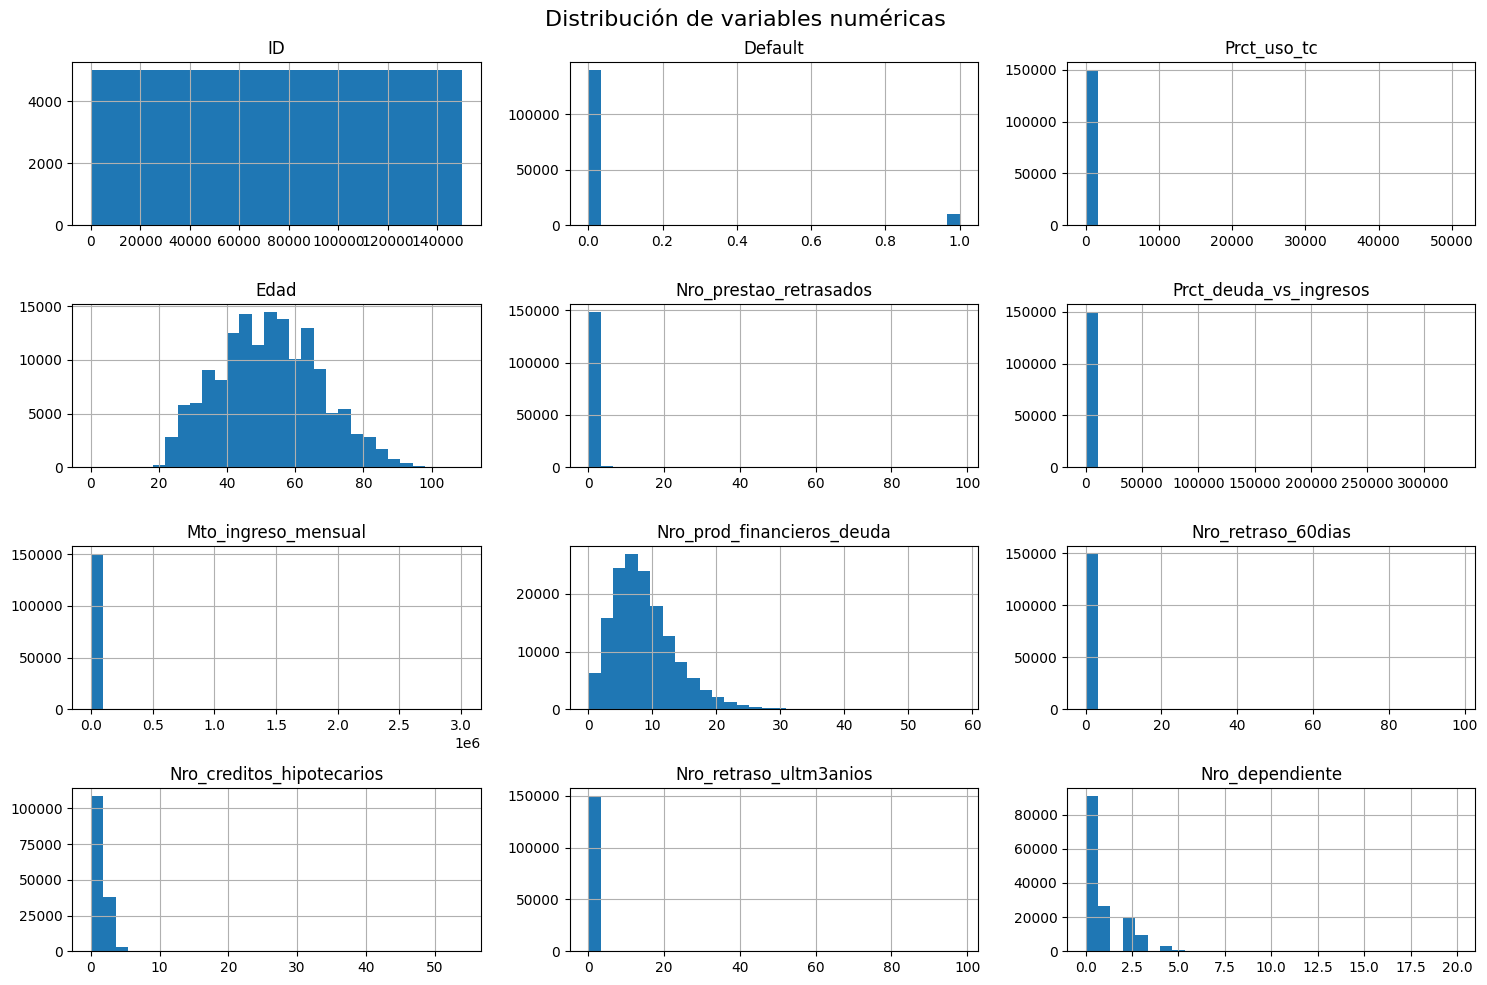

In [10]:
# Filtrar solo columnas numéricas
df_num = df_clase.select_dtypes(include=["int64", "float64"])

# Histograma
df_num.hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribución de variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

#### 3.2 Análisis Bivariado

In [11]:

df_clase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          150000 non-null  int64  
 1   Default                     150000 non-null  int64  
 2   Prct_uso_tc                 150000 non-null  float64
 3   Edad                        150000 non-null  int64  
 4   Nro_prestao_retrasados      150000 non-null  int64  
 5   Prct_deuda_vs_ingresos      150000 non-null  float64
 6   Mto_ingreso_mensual         150000 non-null  int64  
 7   Nro_prod_financieros_deuda  150000 non-null  int64  
 8   Nro_retraso_60dias          150000 non-null  int64  
 9   Nro_creditos_hipotecarios   150000 non-null  int64  
 10  Nro_retraso_ultm3anios      150000 non-null  int64  
 11  Nro_dependiente             150000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 13.7 MB


In [12]:
def bivariado_plot_cat(df, columna, default):
  aux = df[[default,columna]]
  aux = aux.groupby(columna)[default].sum().reset_index()
  sns.lineplot(x = columna, y = default, data = aux)
  plt.xlabel(columna)
  plt.show()

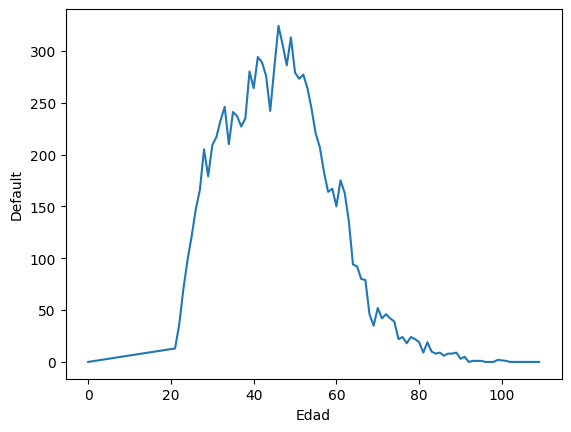

In [13]:
bivariado_plot_cat(df_clase,'Edad','Default')

In [14]:
def bivariado_plot_num(df, columna, default, bins):
  aux = df[[default, columna]]
  aux["Var"] = pd.qcut(aux[columna],bins, labels=False)
  aux = aux.groupby("Var")[default].mean().reset_index()
  sns.lineplot(x = 'Var', y = default, data = aux, markers=True, dashes=False)
  plt.xlabel(columna)
  plt.show()

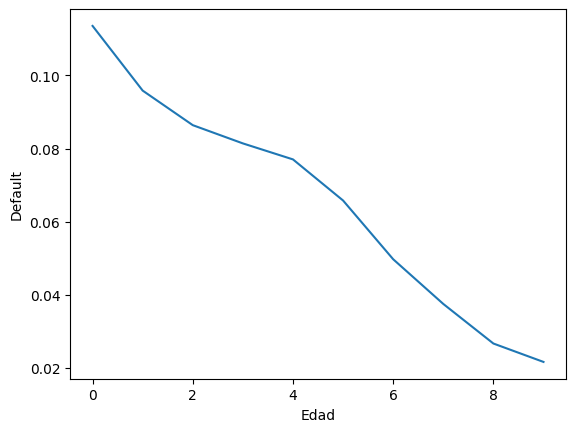

In [15]:
bivariado_plot_num(df_clase,'Edad','Default',10)

### 3.3 Analizaremos las Interacciones entre variables

### Correlaciones

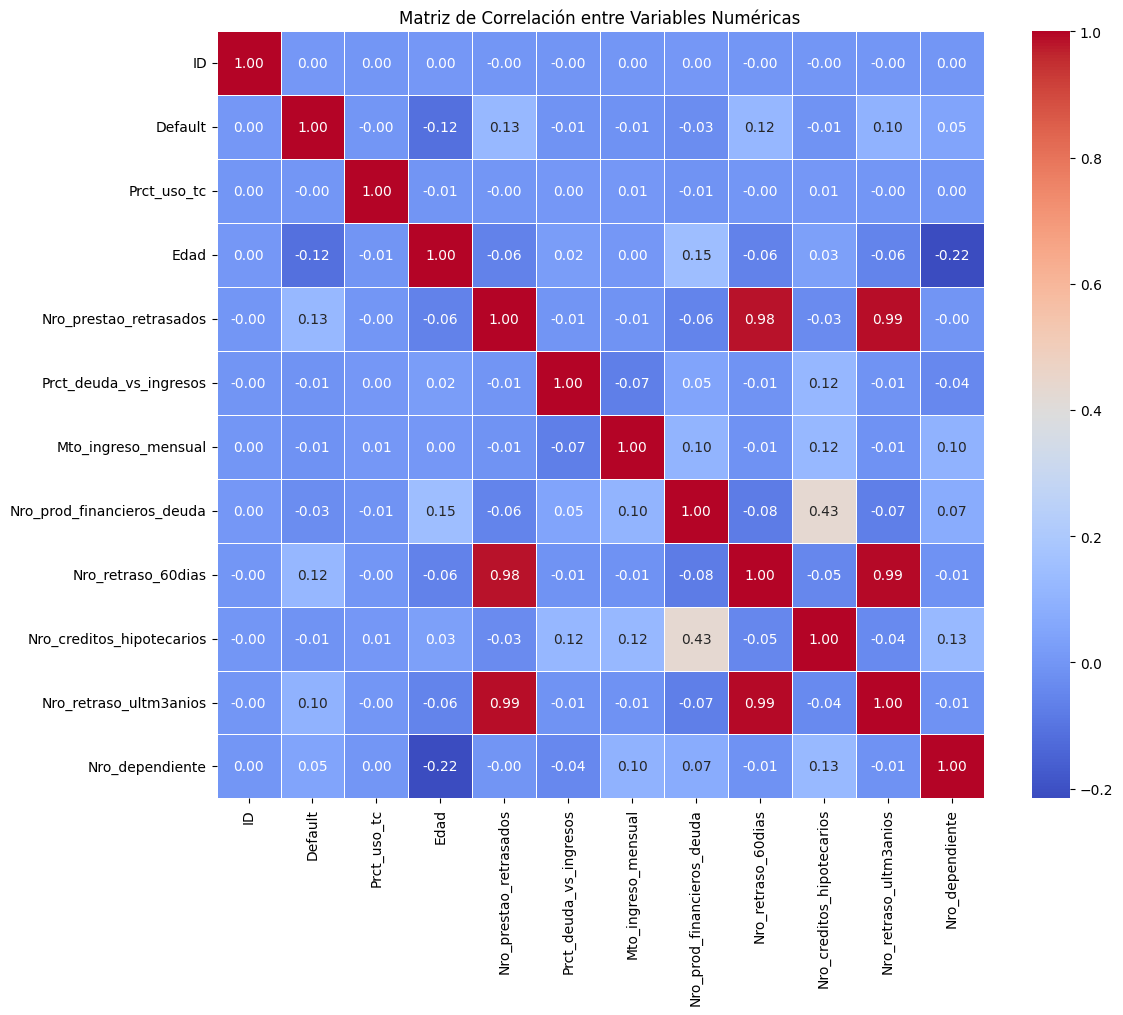

In [16]:
# Seleccionar solo variables numéricas
df_num = df_clase.select_dtypes(include=["int64", "float64"])

# Calcular matriz de correlación
corr_matrix = df_num.corr()

# Graficar
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.tight_layout()
plt.show()

In [18]:
# =========================================
# Modelo de Red Neuronal para Riesgo de Incumplimiento
# =========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar variables predictoras (X) y variable objetivo (y)
X = df_clase.drop("Default", axis=1)   # quitamos la columna target
y = df_clase["Default"]                # target binario: 0 = paga, 1 = incumple


In [19]:
# Escalamiento de variables (solo numéricas)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
# Definición del modelo de red neuronal
modelo_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # salida binaria
])


In [22]:
# Compilación
modelo_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name="auc")]
)


In [23]:
# Entrenamiento
historia = modelo_nn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9269 - auc: 0.6987 - loss: 0.2460 - val_accuracy: 0.9333 - val_auc: 0.8311 - val_loss: 0.1892
Epoch 2/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9338 - auc: 0.8032 - loss: 0.1966 - val_accuracy: 0.9339 - val_auc: 0.8328 - val_loss: 0.1886
Epoch 3/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9344 - auc: 0.8035 - loss: 0.1956 - val_accuracy: 0.9349 - val_auc: 0.8332 - val_loss: 0.1899
Epoch 4/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9335 - auc: 0.8083 - loss: 0.1971 - val_accuracy: 0.9350 - val_auc: 0.8326 - val_loss: 0.1882
Epoch 5/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9356 - auc: 0.8089 - loss: 0.1930 - val_accuracy: 0.9351 - val_auc: 0.8333 - val_loss: 0.1881
Epoch 6/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9350 - auc: 0.8128 - loss: 0.1925 - val_accuracy: 0.9355 - val_auc: 0.8338 - val_loss: 0.1878
Epoch 7/30
3750/3750 ━━━━━

In [26]:
# Evaluación
resultados = modelo_nn.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy: {resultados[1]:.4f}")
print(f"AUC: {resultados[2]:.4f}")

# Predicción de riesgo (probabilidades de incumplimiento)
y_pred_proba = modelo_nn.predict(X_test)

Accuracy: 0.9363
AUC: 0.8384
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 672us/step


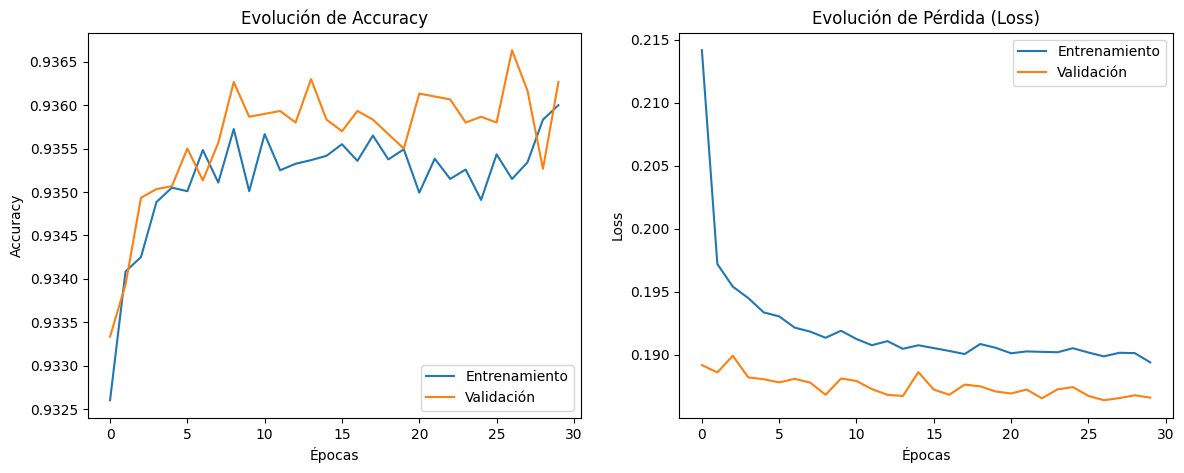

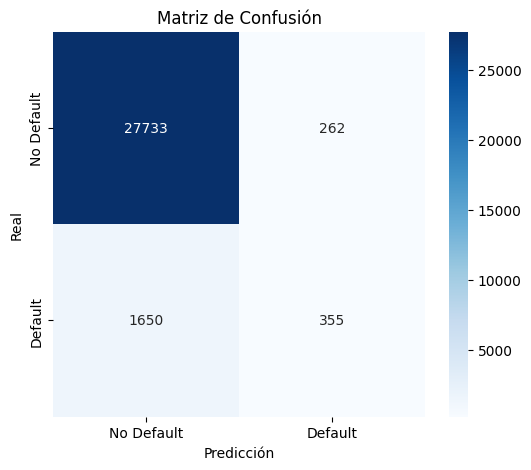


Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.58      0.18      0.27      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.58      0.62     30000
weighted avg       0.92      0.94      0.92     30000



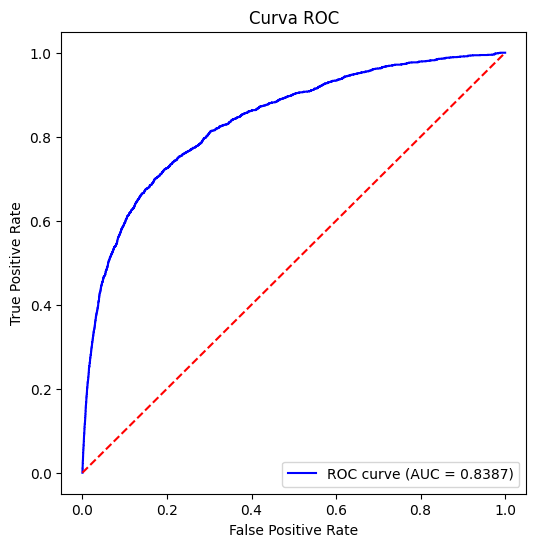

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ==============================
# 1. Curva de entrenamiento (Accuracy y Loss)
# ==============================
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(historia.history['accuracy'], label='Entrenamiento')
plt.plot(historia.history['val_accuracy'], label='Validación')
plt.title("Evolución de Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(historia.history['loss'], label='Entrenamiento')
plt.plot(historia.history['val_loss'], label='Validación')
plt.title("Evolución de Pérdida (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.show()

# ==============================
# 2. Matriz de Confusión
# ==============================
y_pred = (y_pred_proba > 0.5).astype("int32")  # convertir probabilidades a 0/1
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Default", "Default"], yticklabels=["No Default", "Default"])
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# ==============================
# 3. Curva ROC y AUC
# ==============================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()
